# Real Data Performance

This notebook compares the performance of the EM approach to LOOCV approach using real-world datasets.

## Preview Experiment

In [1]:
import numpy as np
import pandas as pd

from fastridge import RidgeEM, RidgeLOOCV
from experiments import run_real_data_experiments
from problems import EmpiricalDataProblem

problems = [
    EmpiricalDataProblem('abalone',    'Rings'),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure'),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength'),
    EmpiricalDataProblem('diabetes',   'target'),
    EmpiricalDataProblem('eye',        'y'),
    EmpiricalDataProblem('forest',     'area'),
    EmpiricalDataProblem('student',    'G3', drop=['G1', 'G2']),
    EmpiricalDataProblem('yacht',      'Residuary_resistance'),   # much lower r2 (0.65 vs. 0.97)
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows'),
]

estimators = {
    'EM':     RidgeEM(),
    'CV_glm': RidgeLOOCV(alphas=100),
    'CV_fix': RidgeLOOCV(alphas=np.logspace(-10, 10, 100, endpoint=True, base=10)),
}

results = run_real_data_experiments(problems, estimators, n_iterations=10, seed=123, verbose=True)
print()

abalone (n=4177, p=9)..........
airfoil (n=1503, p=5)..........
concrete (n=1030, p=8)..........
diabetes (n=442, p=10)..........
eye (n=120, p=200)..........
forest (n=517, p=27)..........
student (n=649, p=39)..........
yacht (n=308, p=6)..........
automobile (n=159, p=51)..........



In [2]:
rows = []
for problem, data_result in zip(problems, results):
    em_time = data_result['EM']['time']
    cv_time = (data_result['CV_glm']['time'] + data_result['CV_fix']['time']) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: data_result[est]['r2'] for est in data_result})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = data_result['EM']['p']
    row['n_train']  = data_result['EM']['n_train']
    row['n:p']      = data_result['EM']['n_train'] / data_result['EM']['p']
    rows.append(row)
pd.DataFrame(rows).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_glm,CV_fix,Speed-Up,p,n_train,n:p
0,abalone,Rings,0.51,0.51,0.51,7.61,9.0,2923,324.78
1,airfoil,scaled-sound-pressure,0.51,0.51,0.51,10.42,5.0,1052,210.40
2,concrete,Concrete compressive strength,0.60,0.60,0.60,8.76,8.0,721,90.12
6,student,G3,0.26,0.26,0.26,6.13,39.0,454,11.64
5,forest,area,-0.08,-0.26,-0.09,2.57,26.2,361,13.78
3,diabetes,target,0.48,0.48,0.48,8.19,10.0,309,30.90
7,yacht,Residuary_resistance,0.65,0.64,0.64,9.02,6.0,215,35.83
8,automobile,price,0.88,0.87,0.85,4.83,50.2,111,2.21
4,eye,y,0.59,0.54,0.34,1.61,200.0,84,0.42


In [3]:
problems_d2 = [
    EmpiricalDataProblem('abalone',    'Rings'),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure'),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength'),
    EmpiricalDataProblem('diabetes',   'target'),
    EmpiricalDataProblem('eye',        'y'),
    # EmpiricalDataProblem('forest',     'area'),  # OHE interaction columns cause SVD failure
    EmpiricalDataProblem('student',    'G3', drop=['G1', 'G2']),
    EmpiricalDataProblem('yacht',      'Residuary_resistance'),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows'),
]

In [4]:
results_d2 = run_real_data_experiments(problems_d2, estimators, n_iterations=10, polynomial=2, seed=123, verbose=True)
print()

abalone (n=4177, p=54)..........
airfoil (n=1503, p=20)..........
concrete (n=1030, p=44)..........
diabetes (n=442, p=65)..........
eye (n=120, p=20300)..........
student (n=649, p=819)..........
yacht (n=308, p=27)..........
automobile (n=159, p=1377)..........



In [5]:
rows_d2 = []
for problem, data_result in zip(problems_d2, results_d2):
    em_time = data_result['EM']['time']
    cv_time = (data_result['CV_glm']['time'] + data_result['CV_fix']['time']) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: data_result[est]['r2'] for est in data_result})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = data_result['EM']['p']
    row['n_train']  = data_result['EM']['n_train']
    row['n:p']      = data_result['EM']['n_train'] / data_result['EM']['p']
    rows_d2.append(row)
pd.DataFrame(rows_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_glm,CV_fix,Speed-Up,p,n_train,n:p
0,abalone,Rings,0.01,0.00,0.00,5.16,53.0,2923,55.15
1,airfoil,scaled-sound-pressure,0.62,0.62,0.62,9.33,20.0,1052,52.60
2,concrete,Concrete compressive strength,0.77,0.77,0.78,6.54,44.0,721,16.39
5,student,G3,0.25,0.20,-2.24,1.61,799.0,454,0.57
3,diabetes,target,0.45,0.45,0.46,5.84,65.0,309,4.75
6,yacht,Residuary_resistance,0.92,0.92,0.92,9.51,27.0,215,7.96
7,automobile,price,0.88,0.86,-1180.10,1.45,1008.5,111,0.11
4,eye,y,0.31,0.31,0.31,1.12,20300.0,84,0.00


In [6]:
problems_d3 = [
    EmpiricalDataProblem('abalone',    'Rings'),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure'),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength'),
    EmpiricalDataProblem('diabetes',   'target'),
    # EmpiricalDataProblem('eye',        'y'),  # excluded in paper for d=3
    # EmpiricalDataProblem('forest',     'area'),  # OHE interaction columns cause SVD failure
    EmpiricalDataProblem('student',    'G3', drop=['G1', 'G2']),
    EmpiricalDataProblem('yacht',      'Residuary_resistance'),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows'),
]

In [7]:
results_d3 = run_real_data_experiments(problems_d3, estimators, n_iterations=10, polynomial=3, seed=123, verbose=True)
print()

abalone (n=4177, p=219)..........
airfoil (n=1503, p=55)..........
concrete (n=1030, p=164)..........
diabetes (n=442, p=285)..........
student (n=649, p=11479)..........
yacht (n=308, p=83)..........
automobile (n=159, p=24803)..........



In [8]:
rows_d3 = []
for problem, data_result in zip(problems_d3, results_d3):
    em_time = data_result['EM']['time']
    cv_time = (data_result['CV_glm']['time'] + data_result['CV_fix']['time']) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: data_result[est]['r2'] for est in data_result})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = data_result['EM']['p']
    row['n_train']  = data_result['EM']['n_train']
    row['n:p']      = data_result['EM']['n_train'] / data_result['EM']['p']
    rows_d3.append(row)
pd.DataFrame(rows_d3).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_glm,CV_fix,Speed-Up,p,n_train,n:p
0,abalone,Rings,-2.22,-2.03,-2.00,3.04,209.0,2923,13.99
1,airfoil,scaled-sound-pressure,0.73,0.73,0.73,5.57,55.0,1052,19.13
2,concrete,Concrete compressive strength,0.84,0.85,0.85,3.19,164.0,721,4.40
4,student,G3,0.22,-0.44,-0.45,0.93,10545.0,454,0.04
3,diabetes,target,0.40,0.40,0.40,2.48,285.0,309,1.08
5,yacht,Residuary_resistance,0.99,0.97,0.99,5.05,83.0,215,2.59
6,automobile,price,0.86,0.80,-630.86,0.68,12079.1,111,0.01


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def make_figure3(results_d1, results_d2, results_d3, output_path=None):
    """2x3 scatter of EM vs CV R² for d=1,2,3. Color = speed-up ratio.

    Top row: CV_glm on y-axis. Bottom row: CV_fix on y-axis.
    Negative R² capped at -0.1. Shared colorbar across all panels.
    """
    results_list = [results_d1, results_d2, results_d3]
    cv_rows = [('CV_glm', 'CV GLM Grid'), ('CV_fix', 'CV Fixed Grid')]
    CLIP_MIN = -0.1

    all_su = [
        dr[cv]['time'] / dr['EM']['time']
        for results in results_list
        for dr in results
        for cv, _ in cv_rows
    ]
    norm = mcolors.Normalize(vmin=min(all_su), vmax=max(all_su))
    cmap = plt.cm.Greens

    fig, axes = plt.subplots(2, 3, figsize=(9, 5.4))
    fig.subplots_adjust(left=0.11, right=0.84, bottom=0.11, top=0.93,
                        hspace=0.06, wspace=0.04)

    for col, results in enumerate(results_list):
        for row, (cv_name, cv_label) in enumerate(cv_rows):
            ax = axes[row, col]

            em_r2 = [max(CLIP_MIN, dr['EM']['r2'])        for dr in results]
            cv_r2 = [max(CLIP_MIN, dr[cv_name]['r2'])     for dr in results]
            su    = [dr[cv_name]['time'] / dr['EM']['time'] for dr in results]

            ax.scatter(em_r2, cv_r2, c=cmap(norm(np.array(su))), s=50, zorder=3,
                       edgecolors='k', linewidths=0.6)
            ax.plot([CLIP_MIN, 1], [CLIP_MIN, 1], 'k--', lw=0.8, zorder=2)
            ax.axhline(0, color='0.8', lw=0.5, zorder=1)
            ax.axvline(0, color='0.8', lw=0.5, zorder=1)
            ax.set_xlim(CLIP_MIN, 1)
            ax.set_ylim(CLIP_MIN, 1)

            ax.set_xticks([0.0, 0.5, 1.0] if col == 0 else [0.5, 1.0])
            ax.set_yticks([0.0, 0.5, 1.0] if row == 0 else [0.0, 0.5])

            if row == 0:
                ax.set_xticklabels([])
            elif col == 0:
                ax.set_xticklabels(['0', '0.5', '1'])
            else:
                ax.set_xticklabels(['0.5', '1'])

            if col > 0:
                ax.set_yticklabels([])
            elif row == 0:
                ax.set_yticklabels(['0', '0.5', '1'])
            else:
                ax.set_yticklabels(['0', '0.5'])

            if row == 1:
                ax.set_xlabel('BayesEM $R^2$')
            if col == 0:
                ax.set_ylabel(f'{cv_label} $R^2$')
            if row == 0:
                ax.set_title(f'd = {col + 1}')

    cbar_ax = fig.add_axes([0.86, 0.28, 0.02, 0.46])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.ax.yaxis.set_label_position('right')
    cbar.set_label('speed-up ratio', rotation=90, labelpad=-30)

    if output_path:
        fig.savefig(output_path, bbox_inches='tight')

In [10]:
import matplotlib.pyplot as plt                                                                                                                                                                                                                                                                             
import matplotlib.colors as mcolors
                                                                                                                                                                                                                                                                                                            
def make_figure3(results_d1, results_d2, results_d3, output_path=None):                                                                                                                                                                                                                                     
    """2x3 scatter of EM vs CV R² for d=1,2,3. Color = speed-up ratio.                                                                                                                                                                                                                                      
                                                                                                                                                                                                                                                                                                            
    Top row: CV_glm on y-axis. Bottom row: CV_fix on y-axis.                                                                                                                                                                                                                                                
    Values below CLIP_MIN=-0.1 are clipped to CLIP_MIN and shown with a dashed edge.                                                                                                                                                                                                                        
    Axis limits extend PAD beyond [CLIP_MIN, 1] so boundary points are fully visible.                                                                                                                                                                                                                       
    """                                                                                                                                                                                                                                                                                                     
    results_list = [results_d1, results_d2, results_d3]                                                                                                                                                                                                                                                     
    cv_rows = [('CV_glm', 'CV GLM Grid'), ('CV_fix', 'CV Fixed Grid')]                                                                                                                                                                                                                                      
    CLIP_MIN = -0.1                                                                                                                                                                                                                                                                                         
    PAD      =  0.03                                                                                                                                                                                                                                                                                        
                                                                                                                                                                                                                                                                                                            
    all_su = [                                                                                                                                                                                                                                                                                              
        dr[cv]['time'] / dr['EM']['time']                                                                                                                                                                                                                                                                   
        for results in results_list                                                                                                                                                                                                                                                                         
        for dr in results                                                                                                                                                                                                                                                                                   
        for cv, _ in cv_rows                                                                                                                                                                                                                                                                                
    ]                                                                                                                                                                                                                                                                                                       
    norm = mcolors.Normalize(vmin=min(all_su), vmax=max(all_su))
    cmap = plt.cm.Greens                                                                                                                                                                                                                                                                                    
                
    fig, axes = plt.subplots(2, 3, figsize=(9, 5.4), sharex=True, sharey=True)                                                                                                                                                                                                                                                        
    fig.subplots_adjust(left=0.11, right=0.84, bottom=0.11, top=0.93,
                        hspace=0.06, wspace=0.04)                                                                                                                                                                                                                                                           
                                                                                                                                                                                                                                                                                                            
    for col, results in enumerate(results_list):                                                                                                                                                                                                                                                            
        for row, (cv_name, cv_label) in enumerate(cv_rows):                                                                                                                                                                                                                                                 
            ax = axes[row, col]                                                                                                                                                                                                                                                                             

            true_em = [dr['EM']['r2']                         for dr in results]                                                                                                                                                                                                                            
            true_cv = [dr[cv_name]['r2']                      for dr in results]
            su      = [dr[cv_name]['time'] / dr['EM']['time'] for dr in results]                                                                                                                                                                                                                            
            disp_em = [max(CLIP_MIN, x) for x in true_em]                                                                                                                                                                                                                                                   
            disp_cv = [max(CLIP_MIN, y) for y in true_cv]                                                                                                                                                                                                                                                   
            clipped = [e < CLIP_MIN or c < CLIP_MIN                                                                                                                                                                                                                                                         
                        for e, c in zip(true_em, true_cv)]                                                                                                                                                                                                                                                   
            colors  = cmap(norm(np.array(su)))                                                                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                                                            
            idx_in  = [i for i, cl in enumerate(clipped) if not cl]
            idx_out = [i for i, cl in enumerate(clipped) if cl]                                                                                                                                                                                                                                             
                                                                                                                                                                                                                                                                                                            
            if idx_in:
                ax.scatter([disp_em[i] for i in idx_in],                                                                                                                                                                                                                                                    
                            [disp_cv[i] for i in idx_in],
                            c=[colors[i] for i in idx_in],                                                                                                                                                                                                                                                   
                            s=50, zorder=3, edgecolors='k', linewidths=0.6)
            if idx_out:                                                                                                                                                                                                                                                                                     
                sc = ax.scatter([disp_em[i] for i in idx_out],
                                [disp_cv[i] for i in idx_out],                                                                                                                                                                                                                                              
                                c=[colors[i] for i in idx_out],                                                                                                                                                                                                                                             
                                s=50, zorder=4, edgecolors='k', linewidths=0.8)
                sc.set_linestyle('--')                                                                                                                                                                                                                                                                      
                
            ax.plot([CLIP_MIN, 1], [CLIP_MIN, 1], 'k--', lw=0.8, zorder=2)                                                                                                                                                                                                                                  
            ax.axhline(0, color='0.8', lw=0.5, zorder=1)
            ax.axvline(0, color='0.8', lw=0.5, zorder=1)                                                                                                                                                                                                                                                    
            ax.set_xlim(CLIP_MIN - PAD, 1 + PAD)                                                                                                                                                                                                                                                            
            ax.set_ylim(CLIP_MIN - PAD, 1 + PAD)                                                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
            if row == 1:                                                                                                                                                                                                                                                                                    
                ax.set_xlabel('BayesEM $R^2$')
                ax.set_xticks([0.0, 0.5, 1.0])
            if col == 0:                                                                                                                                                                                                                                                                                    
                ax.set_ylabel(f'{cv_label} $R^2$')
                ax.set_yticks([0.0, 0.5, 1.0])
            if row == 0:                                                                                                                                                                                                                                                                                    
                ax.set_title(f'$d = {col + 1}$')
                                                                                                                                                                                                                                                                                                            
    cbar_ax = fig.add_axes([0.86, 0.28, 0.02, 0.46])                                                                                                                                                                                                                                                        
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, cax=cbar_ax)                                                                                                                                                                                                                                                                    
    cbar.ax.yaxis.set_label_position('right')                                                                                                                                                                                                                                                               
    cbar.set_label('speed-up ratio', rotation=90, labelpad=-30)                                                                                                                                                                                                                                             
                                                                                                                                                                                                                                                                                                            
    if output_path:
        fig.savefig(output_path, bbox_inches='tight')      

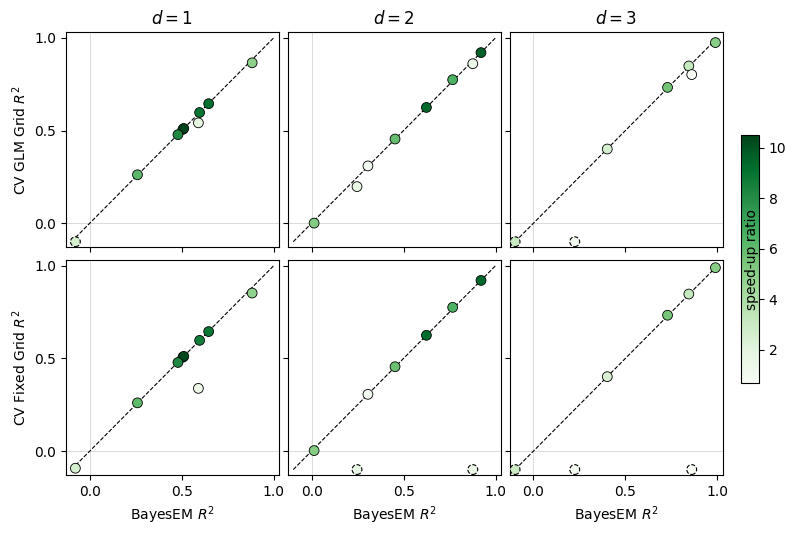

In [11]:
make_figure3(results, results_d2, results_d3)

## Full Experiment: Small and Moderately-sized Datasets

This experiment corresponds to Figure 3 of the appendix.

In [12]:
problems_full = [
    EmpiricalDataProblem('abalone',          'Rings'),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure'),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows'),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=['car_name'], nan_policy='drop_rows'), # could include brand part of car name for increasing p
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=['state', 'fold', 'communityname'],
                         nan_policy='drop_cols'),
    EmpiricalDataProblem('ribo',             'y'),
    EmpiricalDataProblem('eye',              'y'),
    EmpiricalDataProblem('boston',           'medv'),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength'),
    EmpiricalDataProblem('diabetes',         'target'),
    EmpiricalDataProblem('facebook',         'Total Interactions',
                         drop=['comment', 'like', 'share'],
                         nan_policy='drop_rows'),  
    EmpiricalDataProblem('forest',           'area'),
    EmpiricalDataProblem('naval_propulsion', 'GT_compressor_decay', drop=['GT_turbine_decay']),  # 'Ts', 'Tp' could be extra targets, but dropping reduces r2
    EmpiricalDataProblem('naval_propulsion', 'GT_turbine_decay',    drop=['GT_compressor_decay']), # 'Ts', 'Tp' could be extra targets, but dropping reduces r2
    EmpiricalDataProblem('parkinsons',       'motor_UPDRS',         drop=['total_UPDRS']),
    EmpiricalDataProblem('parkinsons',       'total_UPDRS',         drop=['motor_UPDRS']),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area'),
    EmpiricalDataProblem('student',          'G3',                  drop=['G1', 'G2']),
    EmpiricalDataProblem('yacht',            'Residuary_resistance'),
]

estimators_full = {
    'EM':     RidgeEM(),
    'CV_glm': RidgeLOOCV(alphas=100),
    'CV_fix': RidgeLOOCV(alphas=np.logspace(-10, 10, 100, endpoint=True, base=10)),
}

results_full = run_real_data_experiments(problems_full, estimators_full,
                                         n_iterations=100, seed=123, verbose=True)
print()

abalone (n=4177, p=9)....................................................................................................
airfoil (n=1503, p=5)....................................................................................................
automobile (n=159, p=51)....................................................................................................
autompg (n=392, p=7)....................................................................................................
crime (n=1994, p=99)....................................................................................................
ribo (n=71, p=4088)....................................................................................................
eye (n=120, p=200)....................................................................................................
boston (n=506, p=13)....................................................................................................
concrete (n=1030, p=8).......

In [13]:
rows_full = []
for problem, data_result in zip(problems_full, results_full):
    em_time = data_result['EM']['time']
    cv_time = (data_result['CV_glm']['time'] + data_result['CV_fix']['time']) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: data_result[est]['r2'] for est in data_result})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = data_result['EM']['p']
    row['n_train']        = data_result['EM']['n_train']
    row['n:p']            = data_result['EM']['n_train'] / data_result['EM']['p']
    rows_full.append(row)
pd.DataFrame(rows_full).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_glm,CV_fix,Speed Up Ratio,p,n_train,n:p
12,naval_propulsion,GT_compressor_decay,0.84,0.84,0.84,6.57,15.00,8353,556.87
13,naval_propulsion,GT_turbine_decay,0.91,0.91,0.91,6.74,15.00,8353,556.87
15,parkinsons,total_UPDRS,0.17,0.17,0.17,5.69,19.00,4112,216.42
14,parkinsons,motor_UPDRS,0.15,0.15,0.15,5.62,19.00,4112,216.42
0,abalone,Rings,0.53,0.53,0.53,8.66,9.00,2923,324.78
4,crime,ViolentCrimesPerPop,0.66,0.66,0.66,2.59,99.00,1395,14.09
1,airfoil,scaled-sound-pressure,0.51,0.51,0.51,10.92,5.00,1052,210.40
8,concrete,Concrete compressive strength,0.61,0.61,0.61,8.40,8.00,721,90.12
17,student,G3,0.27,0.27,0.27,5.75,39.00,454,11.64
11,forest,area,-0.05,-0.16,-0.05,2.47,26.43,361,13.66


In [14]:
problems_full_d2 = [
    EmpiricalDataProblem('abalone',          'Rings'),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure'),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows'),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=['car_name'], nan_policy='drop_rows'),
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=['state', 'fold', 'communityname'],
                         nan_policy='drop_cols'),
    # EmpiricalDataProblem('ribo',             'y'),  # memory exhaustion at d=2
    EmpiricalDataProblem('eye',              'y'),
    EmpiricalDataProblem('boston',           'medv'),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength'),
    EmpiricalDataProblem('diabetes',         'target'),
    EmpiricalDataProblem('facebook',         'Total Interactions',
                         drop=['comment', 'like', 'share'],
                         nan_policy='drop_rows'),
    # EmpiricalDataProblem('forest',           'area'),  # OHE interaction columns cause SVD failure
    EmpiricalDataProblem('naval_propulsion', 'GT_compressor_decay', drop=['GT_turbine_decay']),
    EmpiricalDataProblem('naval_propulsion', 'GT_turbine_decay',    drop=['GT_compressor_decay']),
    EmpiricalDataProblem('parkinsons',       'motor_UPDRS',         drop=['total_UPDRS']),
    EmpiricalDataProblem('parkinsons',       'total_UPDRS',         drop=['motor_UPDRS']),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area'),
    EmpiricalDataProblem('student',          'G3',                  drop=['G1', 'G2']),
    EmpiricalDataProblem('yacht',            'Residuary_resistance'),
]

In [15]:
results_full_d2 = run_real_data_experiments(problems_full_d2, estimators_full, n_iterations=30, polynomial=2, seed=123, verbose=True)
print()

abalone (n=4177, p=54)..............................
airfoil (n=1503, p=20)..............................
automobile (n=159, p=1377)..............................
autompg (n=392, p=35)..............................
crime (n=1994, p=5049)..............................
eye (n=120, p=20300)..............................
boston (n=506, p=104)..............................
concrete (n=1030, p=44)..............................
diabetes (n=442, p=65)..............................
facebook (n=499, p=170)..............................
naval_propulsion (n=11934, p=152)..............................
naval_propulsion (n=11934, p=152)..............................
parkinsons (n=5875, p=209)..............................
parkinsons (n=5875, p=209)..............................
real_estate (n=414, p=27)..............................
student (n=649, p=819)..............................
yacht (n=308, p=27)..............................



In [16]:
rows_full_d2 = []
for problem, data_result in zip(problems_full_d2, results_full_d2):
    em_time = data_result['EM']['time']
    cv_time = (data_result['CV_glm']['time'] + data_result['CV_fix']['time']) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: data_result[est]['r2'] for est in data_result})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = data_result['EM']['p']
    row['n_train']        = data_result['EM']['n_train']
    row['n:p']            = data_result['EM']['n_train'] / data_result['EM']['p']
    rows_full_d2.append(row)
pd.DataFrame(rows_full_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_glm,CV_fix,Speed Up Ratio,p,n_train,n:p
11,naval_propulsion,GT_turbine_decay,1.00,1.00,1.00,3.40,149.00,8353,56.06
10,naval_propulsion,GT_compressor_decay,1.00,1.00,1.00,3.43,149.00,8353,56.06
13,parkinsons,total_UPDRS,0.24,0.22,0.22,3.09,209.00,4112,19.67
12,parkinsons,motor_UPDRS,0.24,0.19,0.18,3.10,209.00,4112,19.67
0,abalone,Rings,0.30,0.28,0.28,5.13,53.00,2923,55.15
4,crime,ViolentCrimesPerPop,0.66,0.65,-0.80,1.22,5049.00,1395,0.28
1,airfoil,scaled-sound-pressure,0.62,0.62,0.62,9.06,20.00,1052,52.60
7,concrete,Concrete compressive strength,0.78,0.78,0.78,6.43,44.00,721,16.39
15,student,G3,0.27,0.23,-2.21,1.60,798.43,454,0.57
6,boston,medv,0.85,0.84,0.84,3.73,104.00,354,3.40


In [17]:
problems_full_d3 = [
    EmpiricalDataProblem('abalone',          'Rings'),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure'),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows'),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=['car_name'], nan_policy='drop_rows'),
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=['state', 'fold', 'communityname'],
                         nan_policy='drop_cols'),
    # EmpiricalDataProblem('ribo',             'y'),  # memory exhaustion at d>=2
    # EmpiricalDataProblem('eye',              'y'),  # excluded in paper for d=3
    EmpiricalDataProblem('boston',           'medv'),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength'),
    EmpiricalDataProblem('diabetes',         'target'),
    EmpiricalDataProblem('facebook',         'Total Interactions',
                         drop=['comment', 'like', 'share'],
                         nan_policy='drop_rows'),
    # EmpiricalDataProblem('forest',           'area'),  # OHE interaction columns cause SVD failure
    EmpiricalDataProblem('naval_propulsion', 'GT_compressor_decay', drop=['GT_turbine_decay']),
    EmpiricalDataProblem('naval_propulsion', 'GT_turbine_decay',    drop=['GT_compressor_decay']),
    EmpiricalDataProblem('parkinsons',       'motor_UPDRS',         drop=['total_UPDRS']),
    EmpiricalDataProblem('parkinsons',       'total_UPDRS',         drop=['motor_UPDRS']),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area'),
    EmpiricalDataProblem('student',          'G3',                  drop=['G1', 'G2']),
    EmpiricalDataProblem('yacht',            'Residuary_resistance'),
]

In [18]:
results_full_d3 = run_real_data_experiments(problems_full_d3, estimators_full, n_iterations=30, polynomial=3, seed=123, verbose=True)
print()

abalone (n=4177, p=219)..............................
airfoil (n=1503, p=55)..............................
automobile (n=159, p=24803)..............................
autompg (n=392, p=119)..............................
crime (n=1994, p=17652)..............................
boston (n=506, p=559)..............................
concrete (n=1030, p=164)..............................
diabetes (n=442, p=285)..............................
facebook (n=499, p=1139)..............................
naval_propulsion (n=11934, p=968)..............................
naval_propulsion (n=11934, p=968)..............................
parkinsons (n=5875, p=1539)..............................
parkinsons (n=5875, p=1539)..............................
real_estate (n=414, p=83)..............................
student (n=649, p=11479)..............................
yacht (n=308, p=83)..............................



In [19]:
rows_full_d3 = []
for problem, data_result in zip(problems_full_d3, results_full_d3):
    em_time = data_result['EM']['time']
    cv_time = (data_result['CV_glm']['time'] + data_result['CV_fix']['time']) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: data_result[est]['r2'] for est in data_result})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = data_result['EM']['p']
    row['n_train']        = data_result['EM']['n_train']
    row['n:p']            = data_result['EM']['n_train'] / data_result['EM']['p']
    rows_full_d3.append(row)
pd.DataFrame(rows_full_d3).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_glm,CV_fix,Speed Up Ratio,p,n_train,n:p
9,naval_propulsion,GT_compressor_decay,1.00,1.00,1.00,2.56,963.00,8353,8.67
10,naval_propulsion,GT_turbine_decay,1.00,1.00,1.00,2.53,963.00,8353,8.67
11,parkinsons,motor_UPDRS,-0.47,0.28,0.28,1.85,1539.00,4112,2.67
12,parkinsons,total_UPDRS,-0.83,0.27,0.27,1.84,1539.00,4112,2.67
0,abalone,Rings,-0.66,-0.60,-0.60,3.07,209.00,2923,13.99
4,crime,ViolentCrimesPerPop,0.66,0.58,-0.34,1.05,17652.00,1395,0.08
1,airfoil,scaled-sound-pressure,0.73,0.73,0.73,5.37,55.00,1052,19.13
6,concrete,Concrete compressive strength,0.85,0.85,0.85,3.15,164.00,721,4.40
14,student,G3,0.25,-0.40,-0.42,0.91,10529.93,454,0.04
5,boston,medv,0.84,0.84,-163.30,1.81,559.00,354,0.63


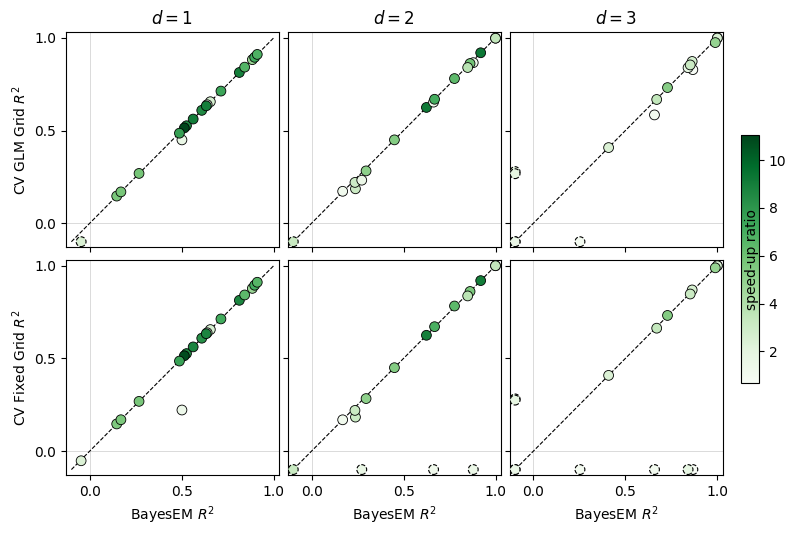

In [20]:
make_figure3(results_full, results_full_d2, results_full_d3,
             output_path='../output/paper2023_figure3.pdf')

In [21]:
problems_large = [
    EmpiricalDataProblem('twitter', 'V78'),
    EmpiricalDataProblem('tomshw', 'V97'),
    EmpiricalDataProblem('blog',   'V281'),
    EmpiricalDataProblem('ct_slices', 'reference'),
]

In [22]:
results_large = run_real_data_experiments(problems_large, estimators_full,
                                          n_iterations=30, seed=123, verbose=True)
print()

twitter (n=583250, p=77)..............................
tomshw (n=28179, p=96)..............................
blog (n=52397, p=280)..............................
ct_slices (n=53500, p=385)..............................



In [23]:
rows_large = []
for problem, data_result in zip(problems_large, results_large):
    em_time = data_result['EM']['time']
    cv_time = (data_result['CV_glm']['time'] + data_result['CV_fix']['time']) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: data_result[est]['r2'] for est in data_result})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = data_result['EM']['p']
    row['n_train']        = data_result['EM']['n_train']
    row['n:p']            = data_result['EM']['n_train'] / data_result['EM']['p']
    rows_large.append(row)
pd.DataFrame(rows_large).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_glm,CV_fix,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,0.93,0.93,0.93,4.49,77.00,408275,5302.27
3,ct_slices,reference,0.86,0.86,0.86,3.49,379.57,37450,98.67
2,blog,V281,0.35,0.35,0.35,3.75,275.23,36677,133.26
1,tomshw,V97,0.96,0.96,0.96,3.52,96.00,19725,205.47


In [24]:
problems_large_d2 = [
    EmpiricalDataProblem('twitter', 'V78'),
    EmpiricalDataProblem('tomshw', 'V97'),
    EmpiricalDataProblem('blog',   'V281'),
    EmpiricalDataProblem('ct_slices', 'reference'),
]

In [25]:
results_large_d2 = run_real_data_experiments(problems_large_d2, estimators_full,
                                              n_iterations=30, polynomial=2,
                                              seed=123, verbose=True)
print()

twitter (n=583250, p=138)..............................
tomshw (n=28179, p=1339)..............................
blog (n=52397, p=948)..............................
ct_slices (n=53500, p=1040)..............................



In [26]:
rows_large_d2 = []
for problem, data_result in zip(problems_large_d2, results_large_d2):
    em_time = data_result['EM']['time']
    cv_time = (data_result['CV_glm']['time'] + data_result['CV_fix']['time']) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: data_result[est]['r2'] for est in data_result})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = data_result['EM']['p']
    row['n_train']        = data_result['EM']['n_train']
    row['n:p']            = data_result['EM']['n_train'] / data_result['EM']['p']
    rows_large_d2.append(row)
pd.DataFrame(rows_large_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_glm,CV_fix,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,0.84,0.87,0.87,4.18,138.00,408275,2958.51
3,ct_slices,reference,0.93,0.93,0.93,2.66,1034.57,37450,36.20
2,blog,V281,0.34,0.34,0.34,2.80,871.30,36677,42.09
1,tomshw,V97,0.93,0.97,0.97,2.28,1339.00,19725,14.73


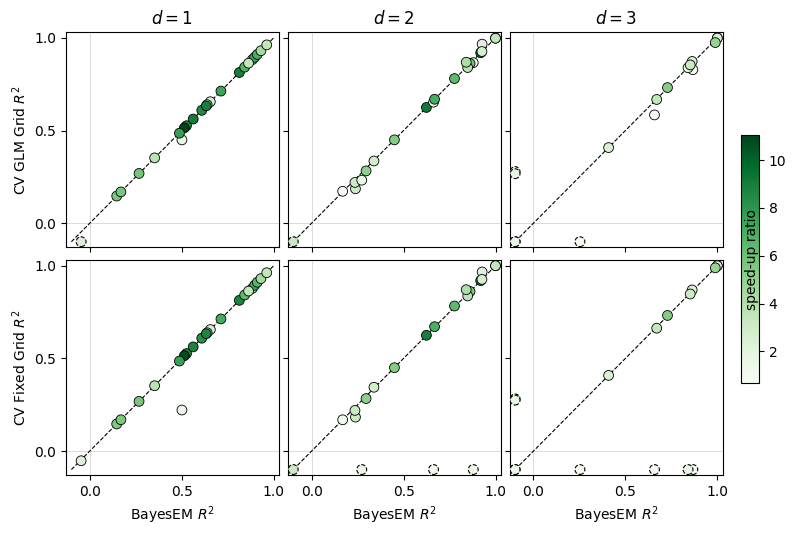

In [27]:
make_figure3(results_full + results_large,
             results_full_d2 + results_large_d2,
             results_full_d3,
             output_path='../output/realdata_r2_by_degree.pdf')